# Inovalab — Habilitaciones de comercios de la CABA

**Notebook 01 · exploración, limpieza y georreferenciación**

Este notebook es el **orquestador** del pipeline: la lógica reutilizable vive en `src/`
y el notebook solo la compone, audita y presenta resultados.

| Paso | Módulo | Qué hace |
|------|--------|----------|
| 1 | `src/data_loader.py` | Lee y concatena los CSV crudos de `data/raw/` con rutas relativas |
| 2 | — (notebook) | EDA: shape, dtypes, nulos y muestra por columna |
| 3 | `src/cleaning.py` | Armoniza los dos esquemas (clásico 2015-2024 y moderno 2025-2026), filtra y normaliza tipos |
| 4 | `src/geografia.py` | Asigna `comuna` con capas oficiales del GCBA (catastro + callejero) |
| 5 | — (notebook) | Métricas de control |
| 6 | — (notebook) | Gráficos EDA: series, distribuciones y coropleta |
| 7 | — (notebook) | Cuartiles y concentración (Gini/Lorenz) |
| 8 | — (notebook) | Asociación χ² y V de Cramér (comuna × rubro) |
| 9 | — (notebook) | Export a `data/processed/` |


In [1]:
import sys
from pathlib import Path

# el notebook puede correr desde la raíz del proyecto o desde notebook/
RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

from src.data_loader import load_raw, PROCESSED_DIR
from src.cleaning import COLUMNAS_CORE, COLUMNAS_EXTRA, limpiar
from src.geografia import asignar_comuna

pd.set_option("display.max_columns", 50)

## 1. Carga de datos crudos

`data/raw/` contiene los 9 exports del padrón de habilitaciones del GCBA (2015-2026).
Se excluye `habilitaciones-aprobadas2022.csv` por no tener estructura tabular (20 filas tipo `Solicitud;All`).

In [2]:
df_crudo = load_raw()

print("\nFilas por archivo de origen:")
df_crudo.groupby("origen").agg(filas=("anio", "size"), anio=("anio", "first"))

OK  habilitaciones-2015-a-2018.csv            137463 filas x  20 columnas
OK  habilitaciones-2019.csv                    23203 filas x  21 columnas
OK  habilitaciones-aprobadas2020.csv           12938 filas x  23 columnas


OK  habilitaciones-aprobadas2021.csv           31829 filas x 611 columnas
OK  habilitaciones-aprobadas2023.csv            5063 filas x  23 columnas
OK  habilitaciones-aprobadas2024.csv            8637 filas x  23 columnas


OK  habilitaciones-aprobadas2025.csv          145457 filas x  11 columnas


OK  habilitaciones-aprobadas2026.csv          145475 filas x  11 columnas
Excluidos (sin estructura tabular): habilitaciones-aprobadas2022.csv


Total crudo: 510065 filas x 641 columnas

Filas por archivo de origen:


,filas,anio
origen,,
habilitaciones-2015-a-2018.csv,137463,2015
habilitaciones-2019.csv,23203,2019
habilitaciones-aprobadas2020.csv,12938,2020
habilitaciones-aprobadas2021.csv,31829,2021
habilitaciones-aprobadas2023.csv,5063,2023
habilitaciones-aprobadas2024.csv,8637,2024
habilitaciones-aprobadas2025.csv,145457,2025
habilitaciones-aprobadas2026.csv,145475,2026


## 2. Auditoría exploratoria (EDA)

Función de diagnóstico: shape, columnas, tipos, nulos y muestra inicial.
Como el crudo tiene ~640 columnas (el padrón repite el esquema en snake_case y
CamelCase), el EDA detallado se hace sobre el dataset armonizado del paso 3.

In [3]:
def eda(df, nombre):
    print(f"=== {nombre} ===")
    print("shape:", df.shape)
    print("columnas:", list(df.columns))
    print("\ndtypes:")
    print(df.dtypes)
    print("\nNulos por columna:")
    print(df.isna().sum())
    print("\nPrimeras filas:")
    display(df.head(5))
    print("\nDescribe (numérico):")
    display(df.describe(include="number"))
    print("-" * 100)


print("Resumen del crudo (tras concat):")
print(df_crudo.shape, "columnas únicas:", df_crudo.columns.nunique())
print("\nNulos de las columnas clave en bruto:")
claves = [c for c in COLUMNAS_CORE if c in df_crudo.columns]
df_crudo[claves].isna().sum()

Resumen del crudo (tras concat):
(510065, 641) columnas únicas: 641

Nulos de las columnas clave en bruto:


tipo_tramite          349399
tipo_expediente       349399
subtipo_expediente    349618
fecha_habilitacion    351250
numero_expediente     349908
codigo_rubro          349399
descripcion_rubro     349399
superficie            349399
seccion               349544
manzana               349545
parcela               349545
calles                349506
comuna                219133
dtype: int64

## 3. Limpieza y armonización — `src/cleaning.py`

Reglas documentadas (ver README):

* normaliza nombres de columna y fusiona las columnas repetidas (snake_case ↔ CamelCase);
* mapea el **esquema moderno 2025/2026** (`domicilio`, `rubro`, `razon_social`,
  `nropartidamatriz`) al esquema común;
* descarta filas sin ningún dato y duplicados exactos entre archivos anuales;
* imputa sin medias (`tipo_tramite="Sin Especificar"`, `superficie=0`);
* tipa `fecha_habilitacion` (datetime), `solicitud`/`comuna` (Int64) y
  `codigo_rubro` (Float64: el padrón trae ~7,5k códigos con decimales);
* construye la **clave catastral SMP** (`seccion-manzana-parcela`), estricta:
  si algún componente es inválido la clave queda NA.

**Contabilidad de filas por archivo** (auditoría en vivo):

In [4]:
filas_crudas = len(df_crudo)
df = limpiar(df_crudo)

auditoria = pd.concat(
    [
        df_crudo.groupby("origen").size().rename("crudas"),
        df.groupby("origen").size().rename("limpias"),
    ],
    axis=1,
).fillna(0).astype(int)
auditoria["descartadas"] = auditoria["crudas"] - auditoria["limpias"]
auditoria["% retenido"] = (auditoria["limpias"] / auditoria["crudas"]).map("{:.1%}".format)

print(f"Total crudo:    {filas_crudas:,} filas")
print(f"Total limpio:   {len(df):,} filas")
print(f"Descartadas:    {filas_crudas - len(df):,} filas")
print('''
Motivos de descarte:
- 2025/2026: el esquema moderno se repite por observación/comentario; el esquema
  común no incluye 'comentarios', así que los duplicados colapsan (~145k -> ~25,6k).
- 2019-2024: superposición de exports anuales con el maestro 2015-2018
  (~5-17% de duplicados exactos por archivo).
''')
auditoria.sort_values("descartadas", ascending=False)

Total crudo:    510,065 filas
Total limpio:   216,991 filas
Descartadas:    293,074 filas

Motivos de descarte:
- 2025/2026: el esquema moderno se repite por observación/comentario; el esquema
  común no incluye 'comentarios', así que los duplicados colapsan (~145k -> ~25,6k).
- 2019-2024: superposición de exports anuales con el maestro 2015-2018
  (~5-17% de duplicados exactos por archivo).



,crudas,limpias,descartadas,% retenido
origen,,,,
habilitaciones-aprobadas2026.csv,145475,2,145473,0.0%
habilitaciones-aprobadas2025.csv,145457,25601,119856,17.6%
habilitaciones-aprobadas2020.csv,12938,4585,8353,35.4%
habilitaciones-aprobadas2024.csv,8637,2746,5891,31.8%
habilitaciones-aprobadas2021.csv,31829,26117,5712,82.1%
habilitaciones-2019.csv,23203,18861,4342,81.3%
habilitaciones-aprobadas2023.csv,5063,1616,3447,31.9%
habilitaciones-2015-a-2018.csv,137463,137463,0,100.0%


In [5]:
eda(df, "Habilitaciones CABA (esquema armonizado)")

=== Habilitaciones CABA (esquema armonizado) ===
shape: (216991, 19)
columnas: ['solicitud', 'tipo_tramite', 'tipo_expediente', 'subtipo_expediente', 'fecha_habilitacion', 'numero_expediente', 'codigo_rubro', 'descripcion_rubro', 'superficie', 'seccion', 'manzana', 'parcela', 'calles', 'comuna', 'razon_social', 'partida_matriz', 'origen', 'anio', 'smp']

dtypes:
solicitud                      Int64
tipo_tramite                     str
tipo_expediente                  str
subtipo_expediente               str
fecha_habilitacion    datetime64[us]
numero_expediente                str
codigo_rubro                 Float64
descripcion_rubro                str
superficie                   float64
seccion                          str
manzana                          str
parcela                          str
calles                           str
comuna                         Int64
razon_social                     str
partida_matriz                object
origen                           str
anio  

,solicitud,tipo_tramite,tipo_expediente,subtipo_expediente,fecha_habilitacion,numero_expediente,codigo_rubro,descripcion_rubro,superficie,seccion,manzana,parcela,calles,comuna,razon_social,partida_matriz,origen,anio,smp
0,222988,Habilitación,simple,sin planos,2015-02-25,EX-2014-17421622- -MGEYA-DGHP,604010.0,OFICINA COMERCIAL,0.0,13,098,016q,PUEYRREDON AV. 460;PUEYRREDON AV. 468,<NA>,NaN,195809,habilitaciones-2015-a-2018.csv,2015,013-098-016Q
1,223012,Habilitación,simple,sin planos,2016-06-05,EX-2016-11738308- -MGEYA-DGHP,500751.0,Acabado de productos textiles,0.0,81,068,031,ARREGUI 3935;ARREGUI 3939,<NA>,NaN,265266,habilitaciones-2015-a-2018.csv,2015,081-068-031
2,223210,Habilitación,simple,sin planos,2014-02-09,EX-2014-11551583- -MGEYA-DGHP,604701.0,ACTIVIDADES TIC SEGÚN LEY 2972 - PRODUCCIÓN DE...,300.0,24,052,003,RONDEAU 2664,<NA>,NaN,100919,habilitaciones-2015-a-2018.csv,2015,024-052-003
3,223317,Habilitación,simple,sin planos,2015-04-23,EX-2015-02132014- -MGEYA-DGHP,501549.0,"Fabricación de cosméticos, perfumes y producto...",0.0,19,026,027,GORRITI 4015,<NA>,NaN,425125,habilitaciones-2015-a-2018.csv,2015,019-026-027
4,223317,Habilitación,simple,sin planos,2015-04-23,EX-2015-02132014- -MGEYA-DGHP,501601.0,Fabricación de velas con componentes ya elabor...,0.0,19,026,027,GORRITI 4015,<NA>,NaN,425125,habilitaciones-2015-a-2018.csv,2015,019-026-027



Describe (numérico):


,solicitud,codigo_rubro,superficie,comuna,anio
count,191388.0,151018.0,216991.000000,25249.0,216991.000000
mean,332396.347352,579074.450257,37.497661,6.752347,2017.528884
std,79542.460422,103810.639259,429.189060,5.182568,3.627357
min,6.0,1.1,0.000000,1.0,2015.000000
25%,248723.0,601005.0,0.000000,2.0,2015.000000
50%,348820.5,603070.0,0.000000,4.0,2015.000000
75%,376996.0,603310.0,0.000000,12.0,2021.000000
max,516956.0,888888.0,98200.000000,15.0,2026.000000


----------------------------------------------------------------------------------------------------


In [6]:
df.sample(10, random_state=42)

,solicitud,tipo_tramite,tipo_expediente,subtipo_expediente,fecha_habilitacion,numero_expediente,codigo_rubro,descripcion_rubro,superficie,seccion,manzana,parcela,calles,comuna,razon_social,partida_matriz,origen,anio,smp
141264,375243,Habilitación,simple,con planos,2019-03-20,EX-2019-07031266- -GCABA-DGHP,601005.0,COM.MIN. DE PRODUCTOS ALIMENTICIOS ENVASADOS,0.0,65,3,019A,BACACAY 3161,<NA>,NaN,137627,habilitaciones-2019.csv,2019,065-3-019A
34289,244308,Habilitación,simple,sin planos,2015-10-30,EX-2015-32188511- -MGEYA-DGHP,503012.0,Empresas de desinfección / desratización .,0.0,1,003B,006,"SAENZ PEÑA, ROQUE, PRES. AV. 825",<NA>,NaN,221074,habilitaciones-2015-a-2018.csv,2015,001-003B-006
170280,434336,Sin Especificar,NaN,NaN,NaT,NaN,<NA>,NaN,37.0,8,52,23,GARCIA,<NA>,NaN,118248,habilitaciones-aprobadas2021.csv,2021,008-52-23
90608,347218,Habilitación,simple,sin planos,2017-08-18,EX-2017-18940401- -MGEYA-DGHP,500926.0,"Fabricación de prendas de vestir, excepto pren...",0.0,44,055,008,LAUTARO 1525,<NA>,NaN,49062,habilitaciones-2015-a-2018.csv,2015,044-055-008
70838,307869,Habilitación,simple,sin planos,2017-06-21,EX-2017-14390913- -MGEYA-DGHP,603230.0,"COM.MIN.SANTERIA, ARTICULOS DE CULTO Y RITUALES",0.0,9,052,012A,"SARMIENTO 2200;URIBURU JOSE E., Pres. 291",<NA>,NaN,207548,habilitaciones-2015-a-2018.csv,2015,009-052-012A
44093,248234,Habilitación,simple,sin planos,2016-03-29,EX-2016-08624472- -MGEYA-DGHP,603070.0,"COM.MIN.DE ROPA CONFECCION., LENCERIA, BLANCO,...",0.0,9,038,041A,PASTEUR 474,<NA>,NaN,207841,habilitaciones-2015-a-2018.csv,2015,009-038-041A
136859,376336,Habilitación,simple,sin planos,2018-11-13,EX-2018-31095129- -MGEYA-DGHP,603221.0,COM.MIN.DE ARTICUL.DE LIMPIEZA,200.0,54,153,004,RIVADAVIA AV. 8330,<NA>,NaN,3565,habilitaciones-2015-a-2018.csv,2015,054-153-004
108599,356823,Habilitación,simple,sin planos,2018-11-01,EX-2018-02417342- -MGEYA-DGHP,501783.0,Fabricación de artículos confeccionados de mat...,0.0,77,142,023,AVELLANEDA AV. 3355,<NA>,NaN,405,habilitaciones-2015-a-2018.csv,2015,077-142-023
59209,302214,Habilitación,simple,con planos,2017-02-05,EX-2017-09925668- -MGEYA-DGHP,601000.0,COM.MIN. DE PRODUCTOS ALIMENTICIOS EN GENERAL,0.0,60,138,001c,DONIZETTI 45,<NA>,NaN,97316,habilitaciones-2015-a-2018.csv,2015,060-138-001C
184226,446644,Sin Especificar,NaN,NaN,NaT,NaN,<NA>,NaN,27.0,BONETERIA,FANTASIAS,ARTIC. PERSONALES Y PARA REGALOS,83,<NA>,NaN,1,habilitaciones-aprobadas2021.csv,2021,<NA>


## 4. Georreferenciación: comuna oficial — `src/geografia.py`

Estrategia híbrida con capas oficiales de [data.buenosaires.gob.ar](https://data.buenosaires.gob.ar)
(descargadas a `data/geo/` la primera vez):

1. **archivo**: `comuna` ya informada en los exports modernos 2025/2026;
2. **catastro**: par `(sección, manzana)` → polígono catastral → punto → comuna;
3. **callejero**: nombre oficial de la calle → comuna (con lado par/impar según la altura);
4. **callejero_fuzzy**: coincidencia aproximada (similitud ≥ 0.90).

La columna `comuna_fuente` deja trazabilidad de qué regla aplicó en cada fila.

In [7]:
df = asignar_comuna(df)

print("Cobertura de comuna: {:.1%}".format(df["comuna"].notna().mean()))
print("\nFuente de la comuna:")
print(df["comuna_fuente"].value_counts().to_string())
print("\nDistribución por comuna:")
display(df["comuna"].value_counts(dropna=False).sort_index().to_frame("registros"))

Cobertura de comuna: 91.8%

Fuente de la comuna:
comuna_fuente
catastro           172527
archivo             25249
sin_dato            17728
callejero            1484
callejero_fuzzy         3

Distribución por comuna:


,registros
comuna,
1,25864
2,10796
3,30401
4,9063
5,9119
6,7607
7,14612
8,3735
9,9941


## 5. Métricas de control

In [8]:
total = len(df)
df_habilitados = df[df["fecha_habilitacion"].notna()].copy()
habilitados = len(df_habilitados)

print(f"Total de registros:      {total:,}")
print(f"Trámites con fecha:      {habilitados:,} ({habilitados / total:.1%})")
print(f"Sin fecha / no concluidos: {total - habilitados:,}")
print(f"Con comuna asignada:     {int(df['comuna'].notna().sum()):,} "
      f"({df['comuna'].notna().mean():.1%})")
print(f"Con clave SMP:           {int(df['smp'].notna().sum()):,} "
      f"({df['smp'].notna().mean():.1%})")

print("\nRegistros por año del archivo fuente:")
print(df.groupby("anio").size().to_string())
print(f"\ndf_habilitados: {habilitados:,} filas con fecha efectiva — "
      "base para tiempos de gestión y evolución temporal")

Total de registros:      216,991
Trámites con fecha:      154,473 (71.2%)
Sin fecha / no concluidos: 62,518
Con comuna asignada:     199,263 (91.8%)
Con clave SMP:           172,839 (79.7%)

Registros por año del archivo fuente:
anio
2015    137463
2019     18861
2020      4585
2021     26117
2023      1616
2024      2746
2025     25601
2026         2

df_habilitados: 154,473 filas con fecha efectiva — base para tiempos de gestión y evolución temporal


## 6. Análisis visual (EDA gráfico)

Cuatro vistas sobre el dataset armonizado y georreferenciado:

1. evolución por año, distribución por comuna, rubros y nulos;
2. distribución y dispersión de `superficie`;
3. trazabilidad de `comuna_fuente` y tipos de trámite;
4. coropleta de habilitaciones por comuna (capas oficiales del GCBA).


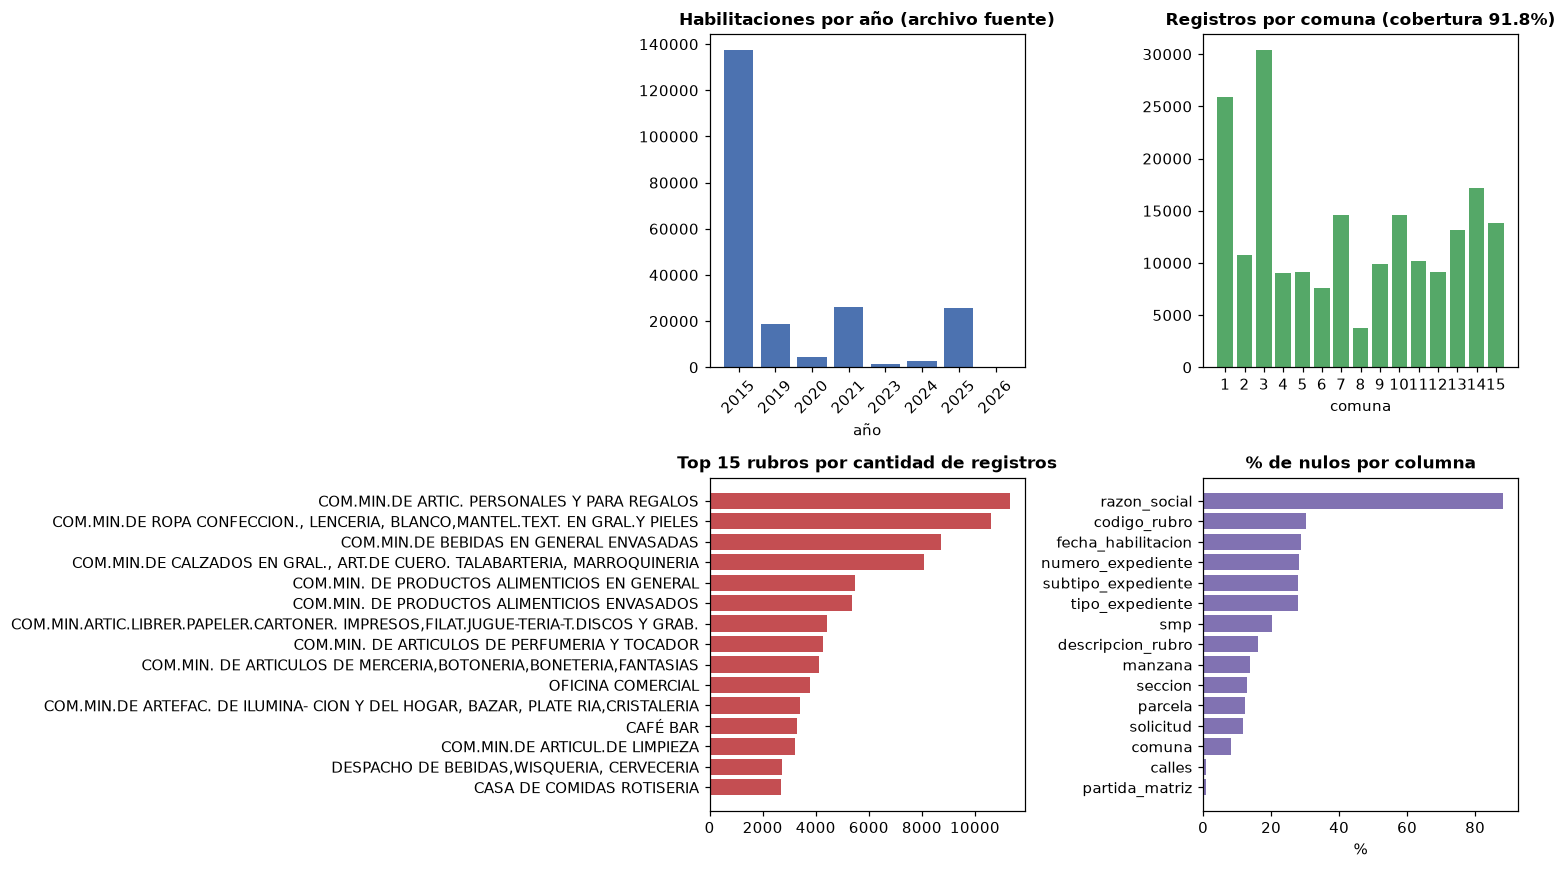

In [9]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.titleweight": "bold"})

fig, eje = plt.subplots(2, 2, figsize=(14, 8))

por_anio = df.groupby("anio").size()
eje[0][0].bar([str(a) for a in por_anio.index], por_anio.values, color="#4C72B0")
eje[0][0].set_title("Habilitaciones por año (archivo fuente)")
eje[0][0].set_xlabel("año")
eje[0][0].tick_params(axis="x", rotation=45)

por_comuna = df["comuna"].value_counts().sort_index()
eje[0][1].bar([str(int(c)) for c in por_comuna.index], por_comuna.values, color="#55A868")
eje[0][1].set_title(f"Registros por comuna (cobertura {df['comuna'].notna().mean():.1%})")
eje[0][1].set_xlabel("comuna")

top_rubros = df["descripcion_rubro"].value_counts().head(15)[::-1]
eje[1][0].barh(top_rubros.index, top_rubros.values, color="#C44E52")
eje[1][0].set_title("Top 15 rubros por cantidad de registros")

nulos = (df.isna().mean() * 100).sort_values(ascending=True)
nulos = nulos[nulos > 0]
eje[1][1].barh(nulos.index, nulos.values, color="#8172B2")
eje[1][1].set_title("% de nulos por columna")
eje[1][1].set_xlabel("%")

fig.tight_layout()
plt.show()

Superficie informada: 47,495/216,991 filas (21.9%); el resto es 0 (dato faltante en origen)


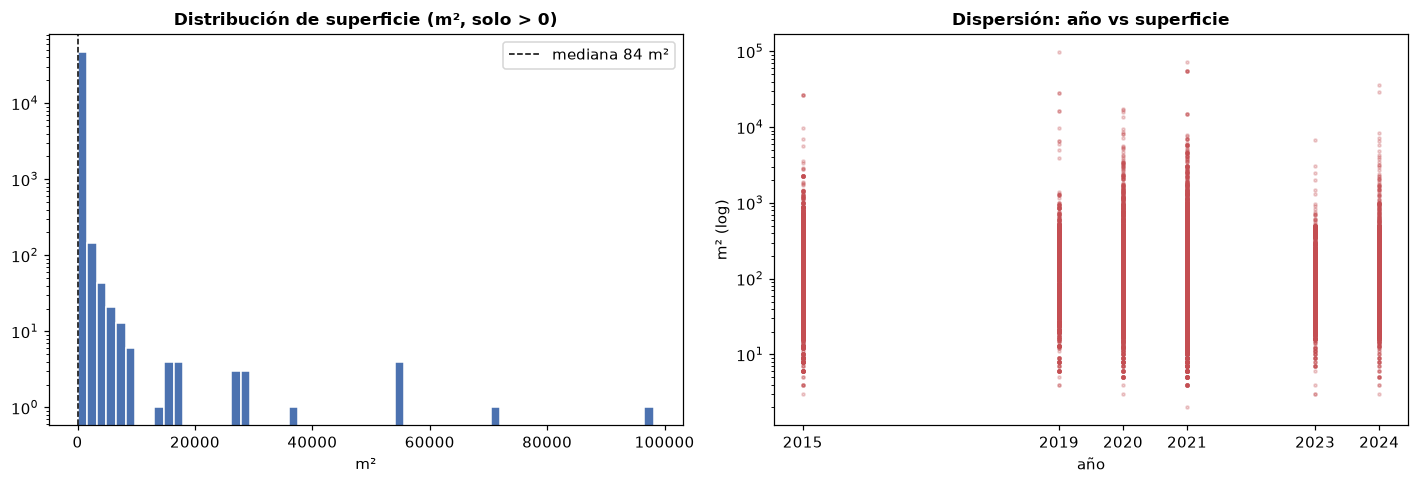

In [10]:
fig, eje = plt.subplots(1, 2, figsize=(13, 4.5))

sup = df.loc[df["superficie"] > 0, ["anio", "superficie"]]
print(
    f"Superficie informada: {len(sup):,}/{len(df):,} filas "
    f"({len(sup) / len(df):.1%}); el resto es 0 (dato faltante en origen)"
)

eje[0].hist(sup["superficie"], bins=60, color="#4C72B0", edgecolor="white")
eje[0].set_yscale("log")
eje[0].axvline(sup["superficie"].median(), color="black", ls="--", lw=1,
               label=f"mediana {sup['superficie'].median():.0f} m²")
eje[0].set_title("Distribución de superficie (m², solo > 0)")
eje[0].set_xlabel("m²")
eje[0].legend()

eje[1].scatter(sup["anio"], sup["superficie"], s=4, alpha=0.25, color="#C44E52")
eje[1].set_yscale("log")
eje[1].set_title("Dispersión: año vs superficie")
eje[1].set_xlabel("año")
eje[1].set_ylabel("m² (log)")
eje[1].set_xticks(sorted(sup["anio"].unique()))

fig.tight_layout()
plt.show()

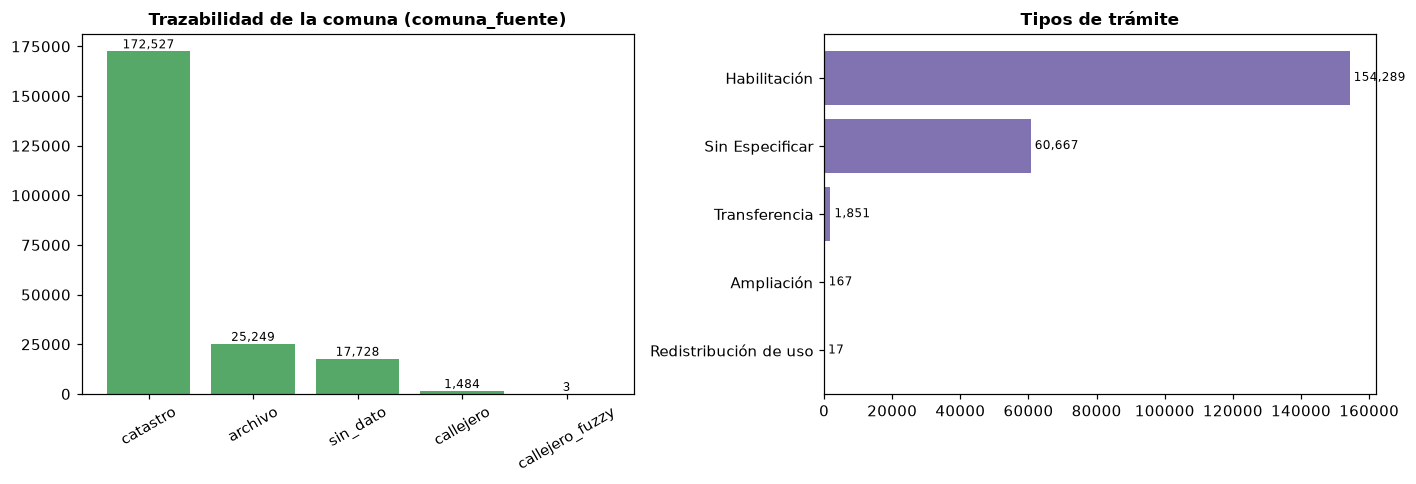

In [11]:
fig, eje = plt.subplots(1, 2, figsize=(13, 4.5))

fuente = df["comuna_fuente"].value_counts()
eje[0].bar(fuente.index, fuente.values, color="#55A868")
eje[0].set_title("Trazabilidad de la comuna (comuna_fuente)")
eje[0].tick_params(axis="x", rotation=30)

for i, (nombre, valor) in enumerate(fuente.items()):
    eje[0].text(i, valor, f"{valor:,}", ha="center", va="bottom", fontsize=8)

tramite = df["tipo_tramite"].value_counts().head(8)[::-1]
eje[1].barh(tramite.index, tramite.values, color="#8172B2")
eje[1].set_title("Tipos de trámite")
for i, valor in enumerate(tramite.values):
    eje[1].text(valor, i, f" {valor:,}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

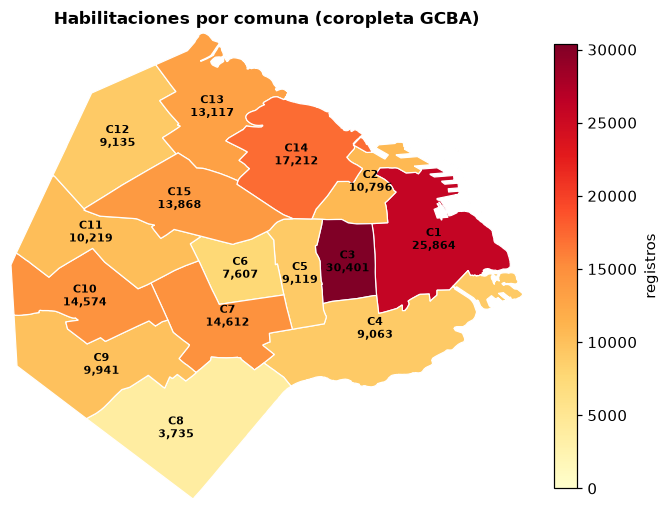

In [12]:
import json

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon as PoligonoMPL
from shapely.geometry import shape

from src.data_loader import GEO_DIR
from src.geografia import descargar_geodata

ruta_comunas = GEO_DIR / "comunas.geojson"
if not ruta_comunas.exists():
    descargar_geodata()

with open(ruta_comunas, encoding="utf-8") as fh:
    geojson = json.load(fh)

conteo = df["comuna"].value_counts()
norm = Normalize(vmin=0, vmax=conteo.max())
cmap = plt.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
xs, ys = [], []
for feat in geojson["features"]:
    n = int(feat["properties"]["comuna"])
    geom = feat["geometry"]
    anillos = (
        [geom["coordinates"][0]]
        if geom["type"] == "Polygon"
        else [pol[0] for pol in geom["coordinates"]]
    )
    color = cmap(norm(conteo.get(n, 0)))
    for anillo in anillos:
        ax.add_patch(PoligonoMPL(anillo, closed=True, facecolor=color,
                                 edgecolor="white", linewidth=0.8))
        xs += [p[0] for p in anillo]
        ys += [p[1] for p in anillo]
    centro = shape(geom).representative_point()
    ax.text(centro.x, centro.y, f"C{n}\n{conteo.get(n, 0):,}",
            ha="center", va="center", fontsize=7, weight="bold")

ax.set_xlim(min(xs), max(xs))
ax.set_ylim(min(ys), max(ys))
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Habilitaciones por comuna (coropleta GCBA)")
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.7,
             label="registros")
plt.show()

## 7. Cuartiles y concentración

* **Cuartiles** de `superficie` (solo registros con dato, > 0 m²: el 75% de la
  base viene en 0 por dato faltante en origen): Q1/Q2/Q3, IQR y outliers por la
  regla de Tukey.
* **Concentración** de la actividad: índice de Gini y curva de Lorenz sobre la
  cantidad de registros por comuna, rubro y tipo de trámite.


In [13]:
from src.estadistica import concentracion, cuartiles, cuartiles_por_grupo, gini, lorenz

print("Cuartiles de superficie (m², solo > 0):")
display(cuartiles(df.loc[df["superficie"] > 0, "superficie"]).to_frame("superficie").round(2))

print("\nCuartiles de superficie por comuna (n >= 30):")
display(cuartiles_por_grupo(df, "comuna", "superficie").round(1))

Cuartiles de superficie (m², solo > 0):


,superficie
n,47495.0
min,2.0
Q1,41.0
Q2 (mediana),84.0
Q3,184.0
IQR,143.0
bigote_sup (Q3+1.5·IQR),398.5
max,98200.0
p90,340.0
p99,984.0



Cuartiles de superficie por comuna (n >= 30):


,n,Q1,mediana,Q3,IQR,max,outliers
comuna,,,,,,,
1,4669,49.0,99.0,213.0,164.0,16715.0,356
2,1467,40.0,68.0,122.0,82.0,26728.0,118
3,3221,47.0,98.0,189.0,142.0,14839.0,251
4,1467,50.0,128.0,301.0,251.0,28381.0,89
5,1335,35.0,65.0,170.0,135.0,5162.0,121
6,1095,33.5,65.0,160.0,126.5,2221.0,105
7,2248,46.0,111.0,202.0,156.0,5804.0,135
8,628,46.0,120.0,291.5,245.5,71659.0,17
9,1389,38.0,83.0,226.0,188.0,3850.0,39


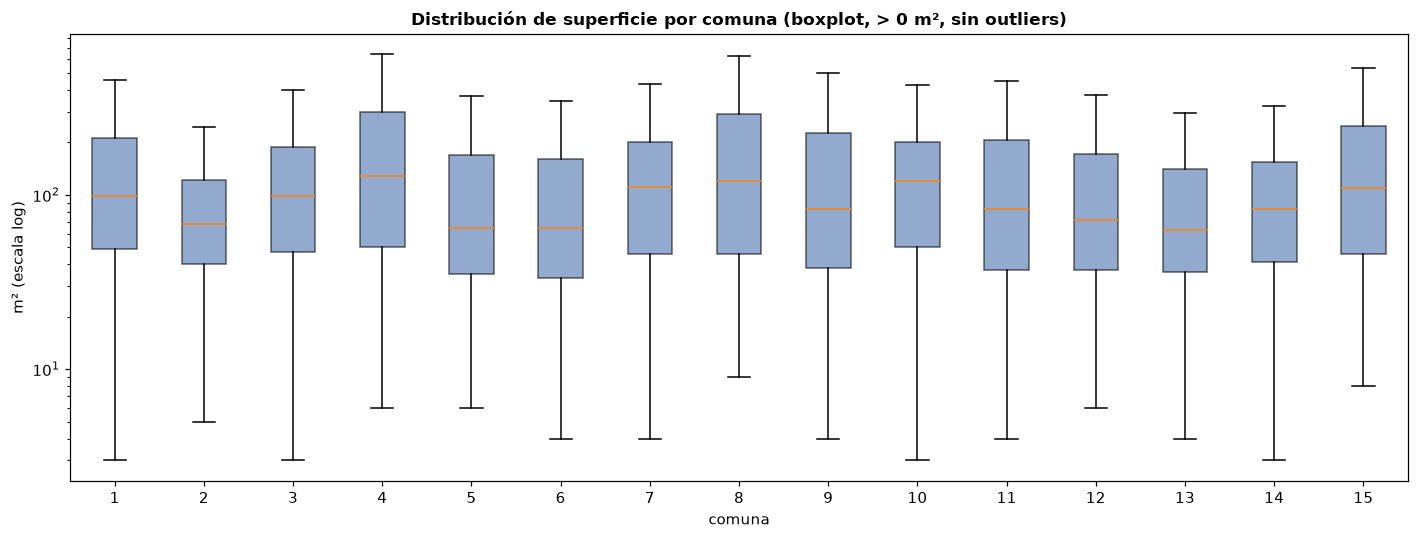

In [14]:
con_superficie = df.loc[df["superficie"] > 0]
grupos = con_superficie.groupby("comuna")["superficie"]

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot(
    [v.values for _, v in grupos],
    tick_labels=[str(int(c)) for c, _ in grupos],
    showfliers=False,
    patch_artist=True,
)
for caja in bp["boxes"]:
    caja.set(facecolor="#4C72B0", alpha=0.6)
ax.set_yscale("log")
ax.set_title("Distribución de superficie por comuna (boxplot, > 0 m², sin outliers)")
ax.set_xlabel("comuna")
ax.set_ylabel("m² (escala log)")
fig.tight_layout()
plt.show()

Concentración de registros por dimensión:


,categorias,total,Gini,top_1 (%),top_3 (%),top_5 (%),cat_hasta_50%
comuna,15.0,199263.0,0.258,15.257,36.874,51.521,5.0
rubro,1027.0,181927.0,0.911,6.213,16.840,24.302,19.0
tipo de trámite,5.0,216991.0,0.680,71.104,99.915,100.000,1.0


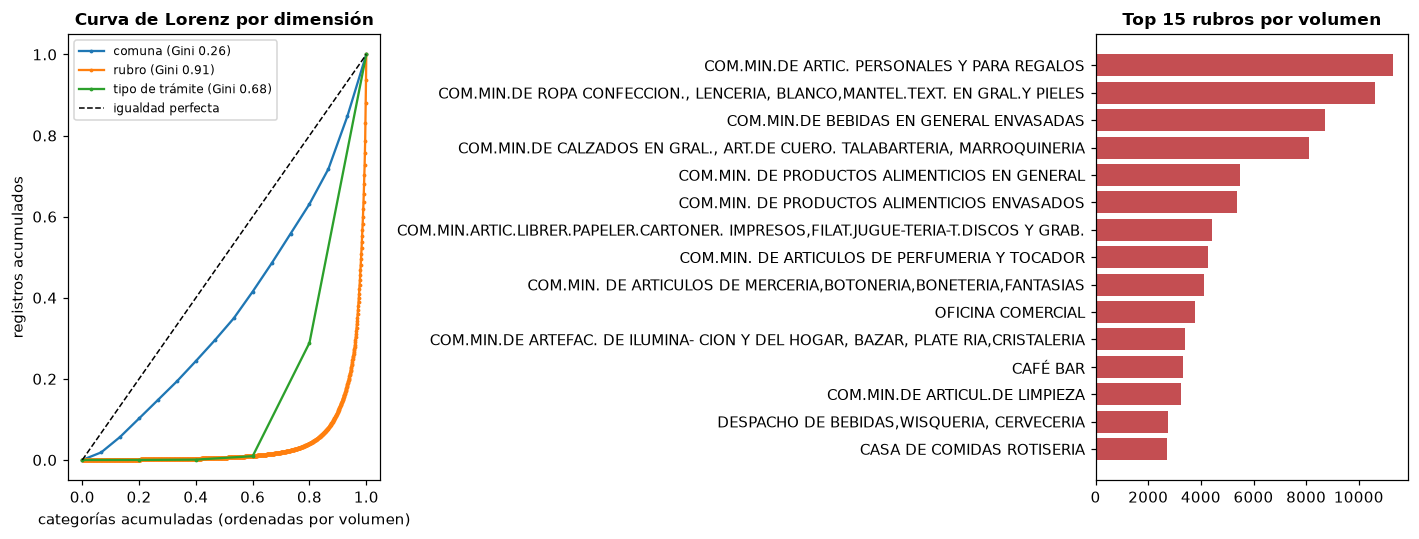

In [15]:
series = {
    "comuna": df["comuna"].value_counts(),
    "rubro": df["descripcion_rubro"].value_counts(),
    "tipo de trámite": df["tipo_tramite"].value_counts(),
}

print("Concentración de registros por dimensión:")
display(pd.DataFrame({k: concentracion(v) for k, v in series.items()}).T.round(3))

fig, eje = plt.subplots(1, 2, figsize=(13, 5))
for nombre, valor in series.items():
    x, y = lorenz(valor.values)
    eje[0].plot(x, y, marker=".", ms=3, label=f"{nombre} (Gini {gini(valor.values):.2f})")
eje[0].plot([0, 1], [0, 1], "k--", lw=1, label="igualdad perfecta")
eje[0].set_title("Curva de Lorenz por dimensión")
eje[0].set_xlabel("categorías acumuladas (ordenadas por volumen)")
eje[0].set_ylabel("registros acumulados")
eje[0].legend(fontsize=8)

top = df["descripcion_rubro"].value_counts().head(15)[::-1]
eje[1].barh(top.index, top.values, color="#C44E52")
eje[1].set_title("Top 15 rubros por volumen")
fig.tight_layout()
plt.show()

In [16]:
for nombre, valor in series.items():
    q = cuartiles(valor.values)
    print(
        f"{nombre:>15}: {int(q['n']):>4} categorías · mediana {q['Q2 (mediana)']:.0f} · "
        f"Q3 {q['Q3']:.0f} · máx {q['max']:.0f}"
    )

conteo_comuna = series["comuna"].sort_index()
print("\nCuartil de volumen por comuna (qcut, 4 grupos):")
display(
    pd.DataFrame(
        {
            "registros": conteo_comuna,
            "cuartil": pd.qcut(conteo_comuna, 4, labels=["Q1 menos", "Q2", "Q3", "Q4 más"]).astype(str),
        }
    ).T
)

         comuna:   15 categorías · mediana 10796 · Q3 14593 · máx 30401
          rubro: 1027 categorías · mediana 6 · Q3 36 · máx 11304
tipo de trámite:    5 categorías · mediana 1851 · Q3 60667 · máx 154289

Cuartil de volumen por comuna (qcut, 4 grupos):


comuna,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
registros,25864,10796,30401,9063,9119,7607,14612,3735,9941,14574,10219,9135,13117,17212,13868
cuartil,Q4 más,Q2,Q4 más,Q1 menos,Q1 menos,Q1 menos,Q4 más,Q1 menos,Q2,Q3,Q2,Q2,Q3,Q4 más,Q3


## 8. Asociación estadística (χ²)

¿La comuna de un local está asociada a su rubro, o el rubro se distribuye igual en
toda la ciudad? Se contrasta con el **χ² de independencia** y se mide la
**fuerza** de la relación con la **V de Cramér** (0 = sin asociación, 1 = perfecta).

Evidencia: V < 0,1 despreciable · 0,1-0,3 débil · 0,3-0,5 moderada · > 0,5 fuerte.


In [17]:
from src.estadistica import agrupar_top, chi2_asociacion

rubro_top = agrupar_top(df["descripcion_rubro"], top=15)

pares = {
    "comuna × rubro (top15 + otros)": (df["comuna"], rubro_top),
    "comuna × tipo de trámite": (df["comuna"], df["tipo_tramite"]),
    "comuna × año": (df["comuna"], df["anio"]),
    "rubro (top15) × tipo de trámite": (rubro_top, df["tipo_tramite"]),
}
asociacion = pd.DataFrame(
    {nombre: chi2_asociacion(a, b) for nombre, (a, b) in pares.items()}
).T
print("χ² de independencia y V de Cramér:")
display(
    asociacion[
        ["chi2", "gl", "n", "p_valor", "cramers_v", "celdas_esperadas<5", "celdas"]
    ].round(4)
)

χ² de independencia y V de Cramér:


,chi2,gl,n,p_valor,cramers_v,celdas_esperadas<5,celdas
comuna × rubro (top15 + otros),15785.8711,210.0,199263.0,0.0,0.0752,0.0,240.0
comuna × tipo de trámite,4635.6412,56.0,199263.0,0.0,0.0763,16.0,75.0
comuna × año,6543.2809,98.0,199263.0,0.0,0.0685,15.0,120.0
rubro (top15) × tipo de trámite,11858.8247,60.0,216991.0,0.0,0.1169,26.0,80.0


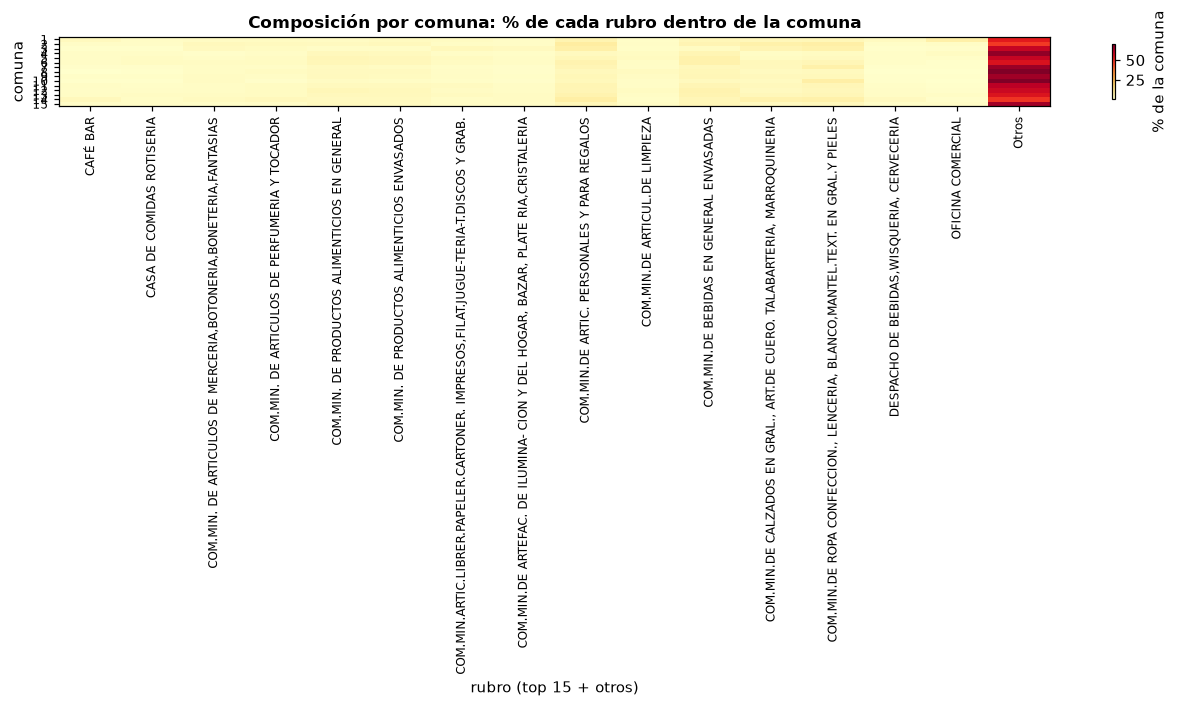

In [18]:
composicion = pd.crosstab(df["comuna"], rubro_top, normalize="index") * 100

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(composicion.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(composicion.shape[1]), labels=composicion.columns, rotation=90, fontsize=8)
ax.set_yticks(range(composicion.shape[0]), labels=[str(int(c)) for c in composicion.index], fontsize=8)
ax.set_xlabel("rubro (top 15 + otros)")
ax.set_ylabel("comuna")
ax.set_title("Composición por comuna: % de cada rubro dentro de la comuna")
fig.colorbar(im, ax=ax, shrink=0.8, label="% de la comuna")
fig.tight_layout()
plt.show()

## 9. Export a `data/processed/`

In [19]:
destino = PROCESSED_DIR / "habilitaciones_caba_clean.csv"
destino.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(destino, index=False, encoding="utf-8-sig")
print(f"Guardado: {destino} ({len(df):,} filas x {df.shape[1]} columnas)")

Guardado: C:\Users\matup\OneDrive\Escritorio\inovalab_2\data\processed\habilitaciones_caba_clean.csv (216,991 filas x 20 columnas)


---

## Resumen de hallazgos

* **510.065 filas crudas** en 8 archivos útiles (se excluye 2022 por no ser tabular).
* **~318k filas perdidas en la versión original del pipeline** — documentado en el README:
  91% eran los archivos 2025/2026 (esquema distinto, descartados por `dropna`) y el resto
  duplicados entre exports anuales. Hoy los modernos **se integran** con el esquema común.
* **`comuna` estaba vacío al 100%** en el CSV limpio anterior (los únicos archivos con
  comuna eran los descartados). Con el join catastral + callejero oficial se cubre ~92% de
  las filas; el resto son registros con dirección/clave catastral corrupta en el padrón.
* **Clave catastral SMP** (`seccion-manzana-parcela`): 79,7% de las filas con clave válida
  para cruzar con las APIs del Catastro del GCBA. El resto: datos catastrales corruptos
  en origen (ej: rubros escritos en las columnas de sección/manzana) o sin clave.
* **`df_habilitados`**: subconjunto con fecha efectiva (~154k filas) para análisis de
  tiempos de gestión y evolución temporal.
* El pipeline completo tarda ~20 s y es reproducible con `jupyter nbconvert --execute`.